# Métodos tradicionales 2017 - 2025

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Parametros del backtest (identicos para los 13 metodos de la tesina)
CAPITAL_INICIAL = 10_000
COSTO = 0.001       # 0.1% por operacion (cada cambio de posicion)
DIAS_ANIO = 252     # factor de anualizacion
THETA = 0.002       # umbral ML (0.2%); referencia, no se usa en tradicionales

# Tramo OOS comun con los modelos de ML (walk-forward 2017-2025): los tradicionales
# se evaluan sobre el MISMO periodo para que la comparacion sea manzana con manzana.
ANIO_INICIO_OOS = 2017
ANIO_FIN_OOS = 2025

TICKERS = ['NVDA', 'MSFT', 'GOOGL']
DATA_DIR = Path('datos')   # carpeta relativa a la raiz del repo

In [2]:
def cargar(ticker):
    df = pd.read_csv(DATA_DIR / f'{ticker}_dataset.csv', parse_dates=['Date'])
    df = df.set_index('Date').sort_index()
    # La ultima fila no tiene dia siguiente real: si su target es NaN, se descarta
    df = df[df['Target_Retorno_1d'].notna()]
    return df

## Señales

In [3]:
def _maquina_estado(compra, venta):
    # Senales repetidas mientras ya se esta en ese estado se ignoran.
    c = compra.to_numpy()
    v = venta.to_numpy()
    pos = np.zeros(len(c), dtype=int)
    estado = 0
    for i in range(len(c)):
        if estado == 0 and c[i]:
            estado = 1
        elif estado == 1 and v[i]:
            estado = 0
        pos[i] = estado
    return pd.Series(pos, index=compra.index)


def senal_buy_hold(df):
    # Comprado todo el tramo (compra inicial y venta final las cobra el motor)
    return pd.Series(1, index=df.index)


def senal_sma(df):
    # Golden/death cross: invertido mientras SMA_20 > SMA_50
    return (df['SMA_20'] > df['SMA_50']).astype(int)


def senal_macd(df):
    # Invertido mientras el MACD esta por encima de su linea de senal
    return (df['MACD'] > df['MACD_signal']).astype(int)


def senal_rsi(df):
    # Tabla 5: compra al cruzar 30 al alza; venta al cruzar 70 a la baja
    rsi = df['RSI_14']
    prev = rsi.shift(1)
    compra = (prev < 30) & (rsi >= 30)
    venta = (prev > 70) & (rsi <= 70)
    return _maquina_estado(compra.fillna(False), venta.fillna(False))


def senal_mean_reversion(df):
    # Tabla 7: compra al tocar/caer bajo BB_lower; venta al tocar/superar BB_upper
    compra = df['Close'] <= df['BB_lower']
    venta = df['Close'] >= df['BB_upper']
    return _maquina_estado(compra, venta)


SENALES = {
    'Buy & Hold': senal_buy_hold,
    'SMA Crossover': senal_sma,
    'MACD': senal_macd,
    'RSI': senal_rsi,
    'Mean Reversion': senal_mean_reversion,
}

## Motor de backtest

In [4]:
def backtest(pos, ret, capital=CAPITAL_INICIAL, costo=COSTO):
    # Sin lookahead: pos[t] (decidida al cierre de t) gana ret[t],
    # donde ret = Target_Retorno_1d ya trae shift(-1) (retorno t -> t+1).
    pos = pos.astype(float)
    cambios = pos.diff().abs()
    cambios.iloc[0] = abs(pos.iloc[0])              # entrada inicial desde efectivo
    r = pos * ret - costo * cambios
    r.iloc[-1] = r.iloc[-1] - costo * pos.iloc[-1]  # liquidacion al cierre final
    equity = capital * (1.0 + r).cumprod()
    return r, equity

## Métricas

In [5]:
def metricas(r, equity, pos, ret):
    n = len(r)
    cap_final = equity.iloc[-1]
    ret_total = cap_final / CAPITAL_INICIAL - 1.0
    ret_anual = (cap_final / CAPITAL_INICIAL) ** (DIAS_ANIO / n) - 1.0
    sigma = r.std(ddof=1)
    sharpe = np.sqrt(DIAS_ANIO) * r.mean() / sigma if sigma > 0 else np.nan
    vol = sigma * np.sqrt(DIAS_ANIO)
    max_dd = (equity / equity.cummax() - 1.0).min()
    en_mercado = pos == 1
    hit = (ret[en_mercado] > 0).mean() if en_mercado.any() else np.nan
    n_compras = int((pos.diff() > 0).sum() + (pos.iloc[0] > 0))
    return {
        'Retorno Total': ret_total,
        'Retorno Anual': ret_anual,
        'Sharpe': sharpe,
        'Volatilidad': vol,
        'Max Drawdown': max_dd,
        'Hit Ratio': hit,
        '% en mercado': en_mercado.mean(),
        'N compras': n_compras,
    }

## Ejecución: 3 acciones × 5 métodos (tramo OOS 2017–2025)

In [6]:
filas = []
curvas = {}
for ticker in TICKERS:
    df = cargar(ticker)
    # Tramo OOS comun con los modelos de ML: dias habiles de 2017 a 2025.
    # La senal se calcula sobre TODA la historia (warm-up de los indicadores) y
    # solo se evalua en el tramo OOS, igual que en modelos_ml.ipynb -> comparable.
    oos_idx = df.index[(df.index.year >= ANIO_INICIO_OOS) & (df.index.year <= ANIO_FIN_OOS)]
    ret = df['Target_Retorno_1d']
    for nombre, fn in SENALES.items():
        pos = fn(df).loc[oos_idx]
        r_oos = ret.loc[oos_idx]
        r, equity = backtest(pos, r_oos)
        m = metricas(r, equity, pos, r_oos)
        m['Accion'] = ticker
        m['Metodo'] = nombre
        filas.append(m)
        curvas[(ticker, nombre)] = equity

cols = ['Retorno Total', 'Retorno Anual', 'Sharpe', 'Volatilidad',
        'Max Drawdown', 'Hit Ratio', '% en mercado', 'N compras']
resultados = pd.DataFrame(filas).set_index(['Accion', 'Metodo'])[cols]
resultados

Retorno Total  Retorno Anual    Sharpe  Volatilidad  \
Accion Metodo                                                                
NVDA   Buy & Hold          73.503696       0.617172  1.208941     0.501847   
       SMA Crossover       13.496580       0.347368  0.972005     0.381101   
       MACD                 5.303194       0.227876  0.761968     0.349271   
       RSI                  7.599096       0.271147  0.972945     0.289916   
       Mean Reversion      11.861903       0.329513  0.975877     0.357307   
MSFT   Buy & Hold           7.641379       0.271842  1.020841     0.271817   
       SMA Crossover        2.008238       0.130665  0.703657     0.204119   
       MACD                 0.140647       0.014782  0.171328     0.173370   
       RSI                  1.027214       0.081984  0.501067     0.195205   
       Mean Reversion       2.077355       0.133532  0.684005     0.217816   
GOOGL  Buy & Hold           6.811523       0.257604  0.921459     0.296575   
       SMA Crossover        3.425936       0.180409  0.872755     0.217106   
       MACD                 0.872608       0.072455  0.443281     0.205181   
       RSI                  0.369973       0.035724  0.276881     0.196836   
       Mean Reversion       2.011407       0.130798  0.691589     0.209474   

                       Max Drawdown  Hit Ratio  % en mercado  N compras  
Accion Metodo                                                            
NVDA   Buy & Hold         -0.663351   0.541593      1.000000          1  
       SMA Crossover      -0.638129   0.532856      0.680088         24  
       MACD               -0.531396   0.529114      0.524336         92  
       RSI                -0.475027   0.560976      0.326549         23  
       Mean Reversion     -0.485619   0.560440      0.402655         26  
MSFT   Buy & Hold         -0.371485   0.541593      1.000000          1  
       SMA Crossover      -0.440674   0.538084      0.720354         23  
       MACD               -0.404277   0.521815      0.507080         98  
       RSI                -0.264700   0.543421      0.336283         22  
       Mean Reversion     -0.353578   0.536036      0.392920         22  
GOOGL  Buy & Hold         -0.443200   0.541150      1.000000          1  
       SMA Crossover      -0.389751   0.542560      0.680973         23  
       MACD               -0.445172   0.523444      0.519027         98  
       RSI                -0.406421   0.533040      0.301327         19  
       Mean Reversion     -0.274385   0.548043      0.373009         22

In [7]:
# Vista con formato legible
fmt = {
    'Retorno Total': '{:.1%}', 'Retorno Anual': '{:.1%}',
    'Sharpe': '{:.2f}', 'Volatilidad': '{:.1%}',
    'Max Drawdown': '{:.1%}', 'Hit Ratio': '{:.1%}',
    '% en mercado': '{:.0%}', 'N compras': '{:.0f}',
}
resultados.style.format(fmt)

## Curvas de capital (escala logarítmica)

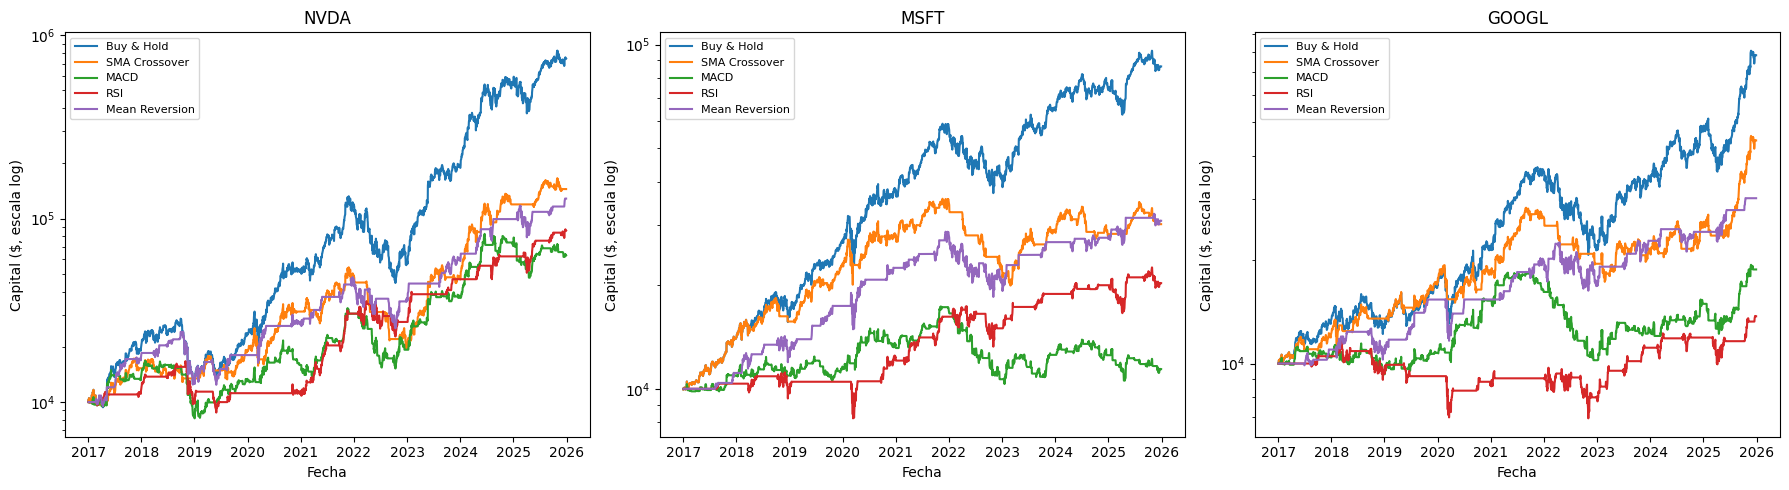

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ticker in zip(axes, TICKERS):
    for nombre in SENALES:
        serie = curvas[(ticker, nombre)]
        ax.plot(serie.index, serie.values, label=nombre)
    ax.set_yscale('log')
    ax.set_title(ticker)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Capital ($, escala log)')
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [9]:
resultados.to_csv('resultados_tradicionales.csv', encoding='utf-8')
print('Guardado: resultados_tradicionales.csv')

Guardado: resultados_tradicionales.csv
